<a href="https://colab.research.google.com/github/noobmaster-ru/diploma/blob/main/v0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Параметры

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize, root_scalar
from scipy.special import roots_hermite
from numpy.linalg import lstsq
import warnings
warnings.filterwarnings('ignore')

# ---------- Параметры ----------
alpha   = 0.33
betta   = 0.95
delta   = 0.025
theta   = 1.25      # CRRA
psi     = 0.75      # disutility of labor exponent
phi     = 5.0
rho     = 0.7
sigma   = 0.01      # сначала лучше поставить маленький шок, потом можно увеличить

def compute_steady_state():
    R = 1.0 / betta + delta - 1.0
    W = ((1.0 - alpha)**(1.0 - alpha) * alpha**alpha / R**alpha) ** (1.0 / (1.0 - alpha))
    K2L = (W / R) * alpha / (1.0 - alpha)
    C2L = K2L**alpha - delta * K2L
    L = ((W / phi) / C2L**theta) ** (1.0 / (psi + theta))
    K = K2L * L
    C = C2L * L
    Y = K**alpha * L**(1.0 - alpha)
    I = delta * K
    return K, L, C, Y, I, R, W

K_ss, L_ss, C_ss, Y_ss, I_ss, R_ss, W_ss = compute_steady_state()
print(f"SS: K={K_ss:.6f}, C={C_ss:.6f}, L={L_ss:.6f}, Y={Y_ss:.6f}, I={I_ss:.6f}")

# ---------- Границы ----------
K_min, K_max = 0.5 * K_ss, 1.5 * K_ss
std_z_uncond = sigma / np.sqrt(1.0 - rho**2)
z_min, z_max = -3.0 * std_z_uncond, 3.0 * std_z_uncond

n_K = 15
n_Z = 9
n_hermite = 7

SS: K=3.114430, C=0.654800, L=0.359216, Y=0.732661, I=0.077861


## 2. Узлы Чебышёва и базис

In [2]:
def chebyshev_nodes(n, a, b):
    x = np.cos((2.0*np.arange(1, n+1) - 1.0) * np.pi / (2.0*n))
    return 0.5*(a+b) + 0.5*(b-a)*x

def chebyshev_polynomials(x, deg, a, b):
    x = np.atleast_1d(x)
    y = 2.0 * (x - a) / (b - a) - 1.0
    y = np.clip(y, -1.0, 1.0)   # защита от выхода из диапазона
    T = np.zeros((len(x), deg))
    T[:, 0] = 1.0
    if deg > 1:
        T[:, 1] = y
    for k in range(2, deg):
        T[:, k] = 2.0 * y * T[:, k-1] - T[:, k-2]
    return T

K_nodes = np.sort(chebyshev_nodes(n_K, K_min, K_max))
z_nodes = np.sort(chebyshev_nodes(n_Z, z_min, z_max))

T_K = chebyshev_polynomials(K_nodes, n_K, K_min, K_max)
T_z = chebyshev_polynomials(z_nodes, n_Z, z_min, z_max)

## Функции модели

In [3]:
def labor_from_KC(K, C, z):
    if K <= 0 or C <= 1e-12:
        return np.nan
    tfp = np.exp(z)
    rhs = (1.0 - alpha) * tfp * (K ** alpha) / (phi * (C ** theta))
    if rhs <= 0:
        return np.nan
    L = rhs ** (1.0 / (psi + alpha))
    if not np.isfinite(L) or L <= 0:
        return np.nan
    return L

def production(K, L, z):
    return np.exp(z) * (K ** alpha) * (L ** (1.0 - alpha))

def rental_rate(K, L, z):
    Y = production(K, L, z)
    return alpha * Y / K

def wage(K, L, z):
    Y = production(K, L, z)
    return (1.0 - alpha) * Y / L

## 4. Начальное приближение

In [4]:
def solve_C_stationary_given_Kz(K, z):
    def res(C):
        L = labor_from_KC(K, C, z)
        if np.isnan(L):
            return 1e8
        Y = production(K, L, z)
        return Y - C - delta * K

    upper = max(2.0 * Y_ss, 2.0 * C_ss)
    try:
        sol = root_scalar(res, bracket=[1e-8, upper], method='brentq')
        if sol.converged:
            return sol.root
    except:
        pass
    return C_ss

def numerical_elasticity():
    eps = 1e-5

    K_pert = K_ss * (1.0 + eps)
    C_pert_K = solve_C_stationary_given_Kz(K_pert, 0.0)
    eta_c_k = (np.log(C_pert_K) - np.log(C_ss)) / eps

    z_pert = eps
    C_pert_z = solve_C_stationary_given_Kz(K_ss, z_pert)
    eta_c_z = (np.log(C_pert_z) - np.log(C_ss)) / eps

    return eta_c_k, eta_c_z

eta_c_k, eta_c_z = numerical_elasticity()
print(f"eta_c_k = {eta_c_k:.6f}, eta_c_z = {eta_c_z:.6f}")

def initial_C(K, z):
    val = C_ss * np.exp(eta_c_k * np.log(K / K_ss) + eta_c_z * z)
    return max(val, 1e-8)

C_init_grid = np.zeros((n_K, n_Z))
for i, K in enumerate(K_nodes):
    for j, z in enumerate(z_nodes):
        C_init_grid[i, j] = initial_C(K, z)

A = np.kron(T_z, T_K)
c_vec = C_init_grid.T.flatten()
theta_init_flat, _, _, _ = lstsq(A, c_vec, rcond=None)

eta_c_k = 0.256680, eta_c_z = 0.970751


## 5. Гаусс–Эрмит и правильное уравнение Эйлера

In [5]:
herm_nodes, herm_weights = roots_hermite(n_hermite)

def gh_expectation(func, z_current):
    mean = rho * z_current
    std = sigma
    z_next_vals = mean + np.sqrt(2.0) * std * herm_nodes
    weights = herm_weights / np.sqrt(np.pi)
    vals = np.array([func(z_next) for z_next in z_next_vals])
    return np.sum(weights * vals)

## 6. Аппроксимация политики C(K,z)

In [6]:
def C_from_theta(K, z, theta_mat):
    K_eval = np.clip(K, K_min, K_max)
    z_eval = np.clip(z, z_min, z_max)

    T_K_pt = chebyshev_polynomials(np.array([K_eval]), n_K, K_min, K_max).flatten()
    T_z_pt = chebyshev_polynomials(np.array([z_eval]), n_Z, z_min, z_max).flatten()

    C = T_K_pt @ theta_mat @ T_z_pt
    return max(C, 1e-8)

## 7. Исправленная невязка Эйлера

In [7]:
def euler_residuals(theta_flat, K_grid_1d, z_grid_1d, penalty=1e6, debug=False):
    theta_mat = theta_flat.reshape((n_K, n_Z))
    residuals = []

    for i, K in enumerate(K_grid_1d):
        for j, z in enumerate(z_grid_1d):
            C = C_from_theta(K, z, theta_mat)
            L = labor_from_KC(K, C, z)

            if np.isnan(L) or L <= 0:
                residuals.append(penalty)
                continue

            Y = production(K, L, z)
            I = Y - C
            K_next = (1.0 - delta) * K + I

            if (not np.isfinite(K_next)) or (K_next <= 1e-10):
                residuals.append(penalty)
                continue

            # штраф за сильный выход за область
            extra_penalty = 0.0
            if K_next < K_min or K_next > K_max:
                extra_penalty += 1e3 * (min(abs(K_next - K_min), abs(K_next - K_max)) / K_ss) ** 2

            def integrand(z_next):
                C_next = C_from_theta(K_next, z_next, theta_mat)
                L_next = labor_from_KC(K_next, C_next, z_next)

                if np.isnan(L_next) or L_next <= 0:
                    return 0.0

                R_next = rental_rate(K_next, L_next, z_next)

                val = (C / C_next) ** theta * (R_next + 1.0 - delta)
                if not np.isfinite(val):
                    return 0.0
                return val

            rhs = betta * gh_expectation(integrand, z)
            resid = 1.0 - rhs
            residuals.append(resid + extra_penalty)

            if debug and i == len(K_grid_1d)//2 and j == len(z_grid_1d)//2:
                print(f"K={K:.4f}, z={z:.4f}, C={C:.4f}, K_next={K_next:.4f}, resid={resid:.4e}")

    return np.array(residuals)

## 8. Оптимизация

In [8]:
print("Проверка начальной невязки...")

init_res = euler_residuals(theta_init_flat, K_nodes, z_nodes)

print(f"SSR initial = {np.sum(init_res**2):.6e}")

print(f"Max abs residual initial = {np.max(np.abs(init_res)):.6e}")

print("Оптимизация коэффициентов...")

result = minimize(

    lambda th: np.sum(euler_residuals(th, K_nodes, z_nodes)**2),

    theta_init_flat,

    method='L-BFGS-B',

    options={'maxiter': 1500, 'ftol': 1e-12, 'gtol': 1e-8, 'disp': True}

)

theta_opt = result.x.reshape((n_K, n_Z))

print("Status:", result.message)

print(f"Final SSR = {result.fun:.6e}")

res_vec = euler_residuals(result.x, K_nodes, z_nodes, debug=True)

print(f"Max abs residual = {np.max(np.abs(res_vec)):.6e}")

Проверка начальной невязки...
SSR initial = 4.784602e+02
Max abs residual initial = 1.081636e+01
Оптимизация коэффициентов...
Status: STOP: TOTAL NO. OF F,G EVALUATIONS EXCEEDS LIMIT
Final SSR = 3.351979e-03
K=3.1144, z=0.0000, C=0.6655, K_next=3.0945, resid=-4.3025e-03
Max abs residual = 2.575350e-02


## 9. Визуализация функции политики

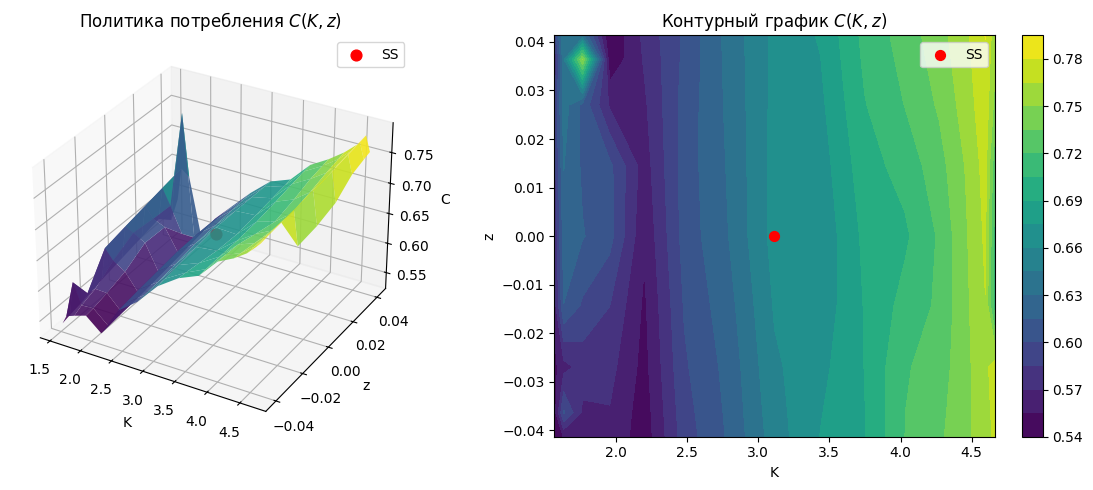

In [18]:
C_opt_grid = np.zeros((n_K, n_Z))

for i, K in enumerate(K_nodes):

    for j, z in enumerate(z_nodes):

        C_opt_grid[i, j] = C_from_theta(K, z, theta_opt)

K_mesh, z_mesh = np.meshgrid(K_nodes, z_nodes, indexing='ij')

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(121, projection='3d')

ax1.plot_surface(K_mesh, z_mesh, C_opt_grid, cmap='viridis', edgecolor='none', alpha=0.9)

ax1.scatter([K_ss], [0.0], [C_ss], color='red', s=60, label='SS')

ax1.set_xlabel('K')

ax1.set_ylabel('z')

ax1.set_zlabel('C')

ax1.set_title('Политика потребления $C(K,z)$')

ax1.legend()

ax2 = fig.add_subplot(122)

cont = ax2.contourf(K_mesh, z_mesh, C_opt_grid, levels=20, cmap='viridis')

ax2.scatter([K_ss], [0.0], color='red', s=50, label='SS')

ax2.set_xlabel('K')

ax2.set_ylabel('z')

ax2.set_title('Контурный график $C(K,z)$')

ax2.legend()

plt.colorbar(cont, ax=ax2)

plt.tight_layout()

plt.show()

## 10. Симуляция глобального стохастического решения

In [16]:
def simulate_global_irf(theta_mat, T_sim=40, shock_size=None):

    if shock_size is None:

        shock_size = sigma

    z_path = np.zeros(T_sim)

    z_path[0] = shock_size

    for t in range(1, T_sim):

        z_path[t] = rho * z_path[t-1]

    K_path = np.zeros(T_sim + 1)

    C_path = np.zeros(T_sim)

    L_path = np.zeros(T_sim)

    Y_path = np.zeros(T_sim)

    I_path = np.zeros(T_sim)

    K_path[0] = K_ss

    for t in range(T_sim):

        K_t = K_path[t]

        z_t = z_path[t]

        C_t = C_from_theta(K_t, z_t, theta_mat)

        L_t = labor_from_KC(K_t, C_t, z_t)

        Y_t = production(K_t, L_t, z_t)

        I_t = Y_t - C_t

        K_next = (1.0 - delta) * K_t + I_t

        C_path[t] = C_t

        L_path[t] = L_t

        Y_path[t] = Y_t

        I_path[t] = I_t

        K_path[t+1] = max(K_next, 1e-8)

    return {

        'z': z_path,

        'K': K_path[:-1],

        'C': C_path,

        'L': L_path,

        'Y': Y_path,

        'I': I_path

    }

def pct_dev(x, x_ss):

    return 100.0 * (x / x_ss - 1.0)

sim_global = simulate_global_irf(theta_opt, T_sim=40, shock_size=sigma)

## 11. Графики IRF со стационарным состоянием

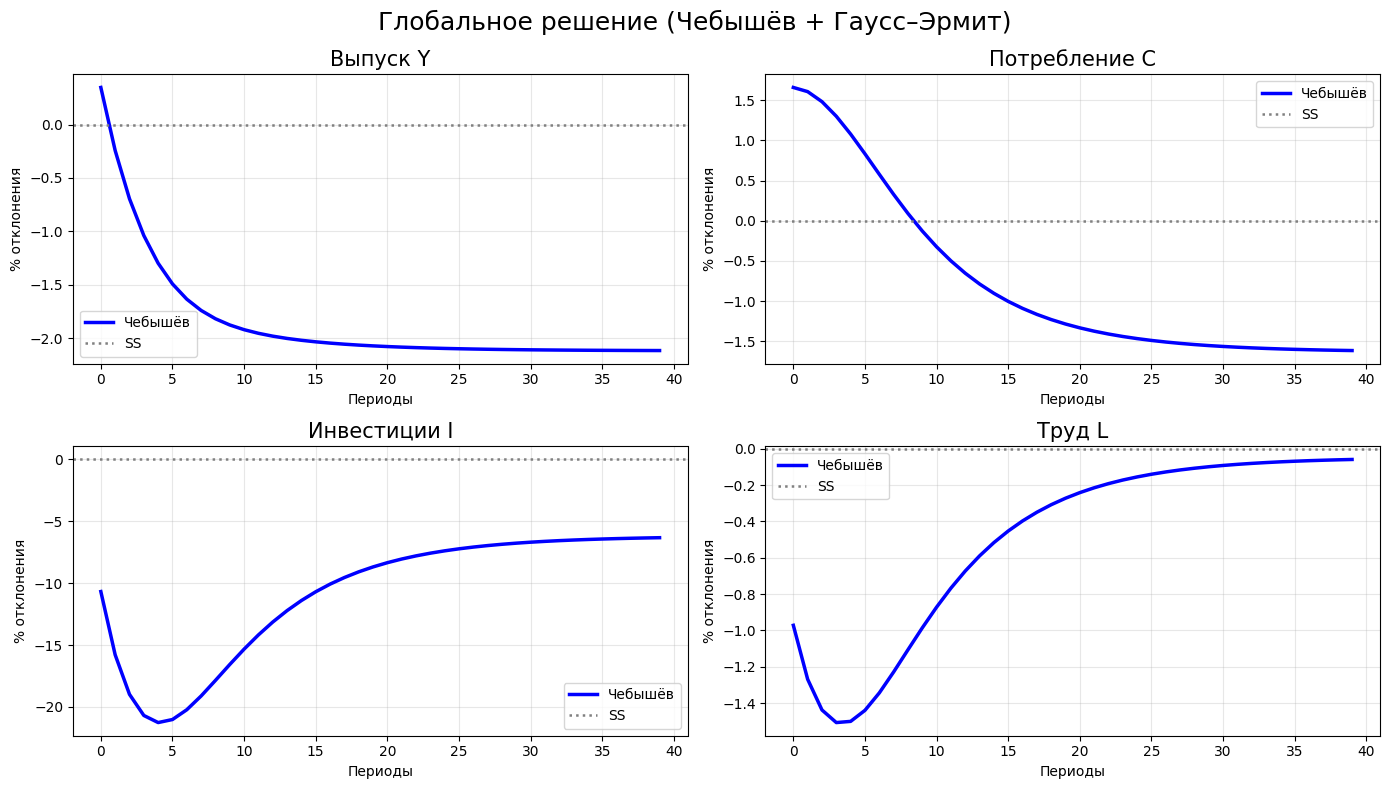

In [17]:
def plot_global_irf(sim):
    t = np.arange(len(sim['Y']))

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Глобальное решение (Чебышёв + Гаусс–Эрмит)', fontsize=18)

    series = [
        ('Y', Y_ss, 'Выпуск Y'),
        ('C', C_ss, 'Потребление C'),
        ('I', I_ss, 'Инвестиции I'),
        ('L', L_ss, 'Труд L'),
    ]

    for ax, (key, ss, title) in zip(axes.ravel(), series):
        ax.plot(t, pct_dev(sim[key], ss), color='blue', lw=2.5, label='Чебышёв')
        ax.axhline(0.0, color='gray', ls=':', lw=1.8, label='SS')
        ax.set_title(title, fontsize=15)
        ax.set_xlabel('Периоды')
        ax.set_ylabel('% отклонения')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

plot_global_irf(sim_global)

## 12. Как сравнивать с Dynare

In [19]:
def plot_compare_irfs(sim_global, dynare_irfs, T=40):
    t = np.arange(T)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle('Сравнение: локальное решение (Dynare) vs глобальное решение (Чебышёв)', fontsize=18)

    comparison = [
        ('Y', Y_ss, dynare_irfs['Y'], 'Выпуск Y'),
        ('C', C_ss, dynare_irfs['C'], 'Потребление C'),
        ('I', I_ss, dynare_irfs['I'], 'Инвестиции I'),
        ('L', L_ss, dynare_irfs['L'], 'Труд L'),
    ]

    for ax, (key, ss, dyn, title) in zip(axes.ravel(), comparison):
        glob = pct_dev(sim_global[key][:T], ss)

        ax.plot(t, dyn[:T], 'r--', lw=2.5, label='Dynare')
        ax.plot(t, glob, 'b-', lw=2.2, label='Чебышёв')
        ax.axhline(0.0, color='gray', ls=':', lw=1.6, label='SS')

        ax.set_title(title, fontsize=15)
        ax.set_xlabel('Периоды')
        ax.set_ylabel('% отклонения')
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.tight_layout()
    plt.show()

Первые 5 значений Dynare:
Y: [0.06050803 0.04312899 0.03151103 0.02282894 0.01666632]
C: [0.01778909 0.01660782 0.01548598 0.0142852  0.01312991]
I: [0.04271893 0.02652116 0.01602505 0.00854374 0.00353641]
L: [-0.01095852 -0.00873878 -0.00711108 -0.00595071 -0.00513291]


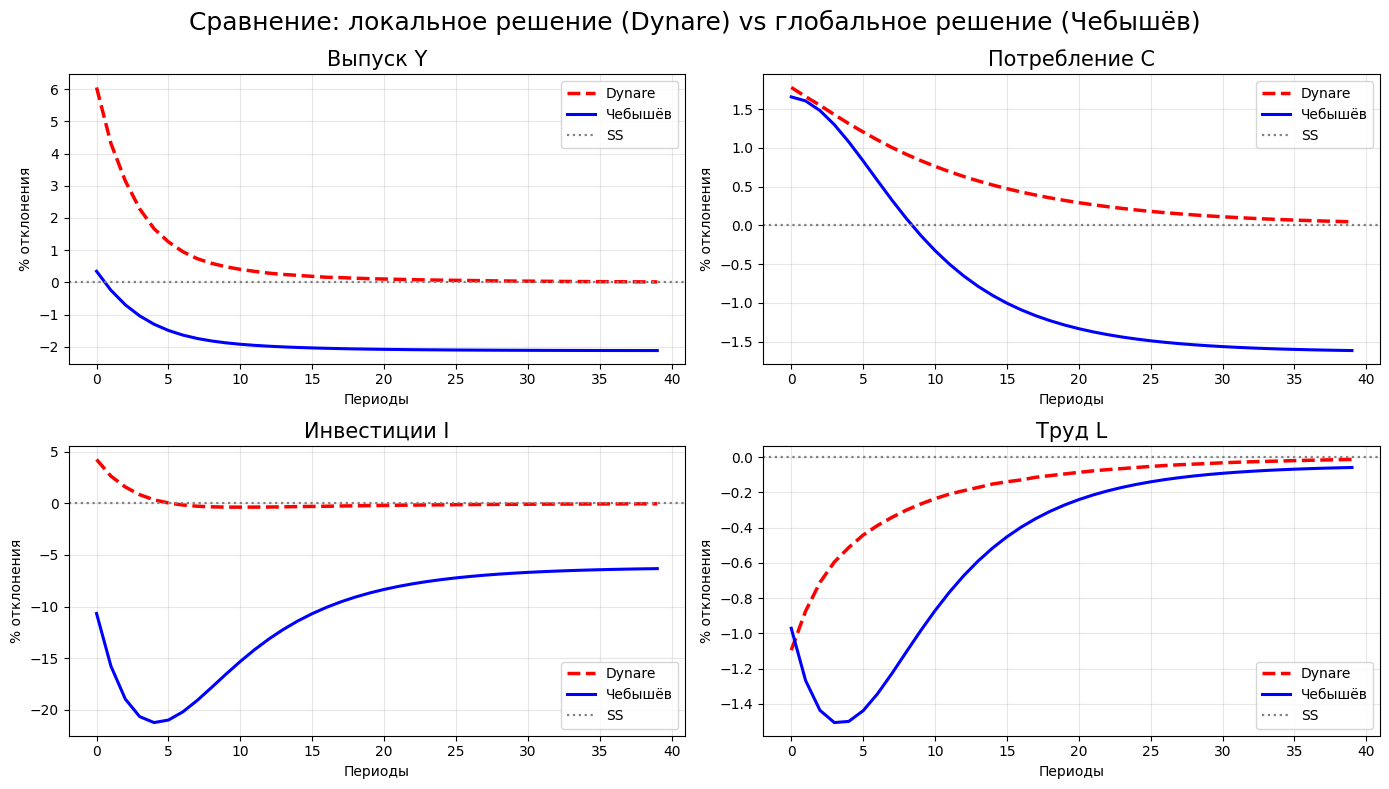

In [26]:
from scipy.io import loadmat
import numpy as np

mat = loadmat("dynare_irf.mat")

y_dyn = np.array(mat["Y_irf"]).flatten()
c_dyn = np.array(mat["C_irf"]).flatten()
i_dyn = np.array(mat["I_irf"]).flatten()
l_dyn = np.array(mat["L_irf"]).flatten()

print("Первые 5 значений Dynare:")
print("Y:", y_dyn[:5])
print("C:", c_dyn[:5])
print("I:", i_dyn[:5])
print("L:", l_dyn[:5])

# Вариант 1: Dynare в долях -> переводим в %
dynare_irfs = {
    "Y": 100 * y_dyn,
    "C": 100 * c_dyn,
    "I": 100 * i_dyn,
    "L": 100 * l_dyn,
}

T = min(40, len(y_dyn), len(sim_global["Y"]))
plot_compare_irfs(sim_global, dynare_irfs, T=T)

In [24]:
import numpy as np
from scipy.io import loadmat

mat = loadmat("dynare_irf.mat")
print("Верхние ключи:")
print(mat.keys())

# --- Случай 1: в файле уже лежат Y,C,I,L ---
simple_keys = [k for k in mat.keys() if not k.startswith("__")]
print("\nПользовательские ключи:")
print(simple_keys)

if all(k in simple_keys for k in ["Y", "C", "I", "L"]):
    y_dyn = mat["Y"].flatten()
    c_dyn = mat["C"].flatten()
    i_dyn = mat["I"].flatten()
    l_dyn = mat["L"].flatten()

else:
    # --- Случай 2: стандартный Dynare mat ---
    oo = mat["oo_"]
    print("\noo dtype names:")
    print(oo.dtype.names)

    irfs = oo["irfs"][0, 0]
    print("\nirfs dtype names:")
    print(irfs.dtype.names)

    # Замени имена ниже на те, которые реально покажет print(irfs.dtype.names)
    y_dyn = irfs["y_e"][0, 0].flatten()
    c_dyn = irfs["c_e"][0, 0].flatten()
    i_dyn = irfs["i_e"][0, 0].flatten()
    l_dyn = irfs["l_e"][0, 0].flatten()

# Обычно Dynare -> умножаем на 100
dynare_irfs = {
    "Y": 100 * y_dyn,
    "C": 100 * c_dyn,
    "I": 100 * i_dyn,
    "L": 100 * l_dyn,
}

print("\nПервые значения Dynare IRF:")
print("Y:", dynare_irfs["Y"][:5])
print("C:", dynare_irfs["C"][:5])
print("I:", dynare_irfs["I"][:5])
print("L:", dynare_irfs["L"][:5])

plot_compare_irfs(sim_global, dynare_irfs, T=40)

Верхние ключи:
dict_keys(['__header__', '__version__', '__globals__', 'Y_irf', 'C_irf', 'I_irf', 'L_irf'])

Пользовательские ключи:
['Y_irf', 'C_irf', 'I_irf', 'L_irf']


KeyError: 'oo_'

In [25]:
import matplotlib.pyplot as plt
t = np.arange(min(40, len(y_dyn)))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
fig.suptitle("Dynare IRF", fontsize=18)

series = [
    (100 * y_dyn[:len(t)], "Выпуск Y"),
    (100 * c_dyn[:len(t)], "Потребление C"),
    (100 * i_dyn[:len(t)], "Инвестиции I"),
    (100 * l_dyn[:len(t)], "Труд L"),
]

for ax, (arr, title) in zip(axes.ravel(), series):
    ax.plot(t, arr, 'r--', lw=2.3, label='Dynare')
    ax.axhline(0.0, color='gray', ls=':', lw=1.5, label='SS')
    ax.set_title(title)
    ax.set_xlabel("Периоды")
    ax.set_ylabel("% отклонения")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

NameError: name 'y_dyn' is not defined